In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [154]:
df= pd.read_csv("shop_smart_ecommerce.csv")

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [28]:
# No missing values

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [30]:
df["VisitorType"].unique()

array(['Returning_Visitor', 'New_Visitor', 'Other'], dtype=object)

In [64]:
# handeling datatypes
catagorial_col= df.select_dtypes(include=["object"]).columns
numerical_col= df.select_dtypes(include=["number"]).columns

# EDA

Text(0.5, 1.0, 'Customer Byed or not')

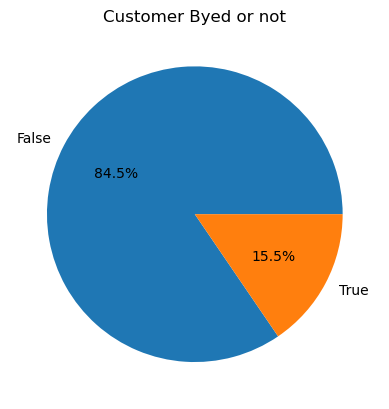

In [54]:
# how much balenced?
no= df["Revenue"].value_counts()
plt.pie(no, labels= ["False","True"],autopct="%1.1f%%")
plt.title("Customer Byed or not")
# unbalenced

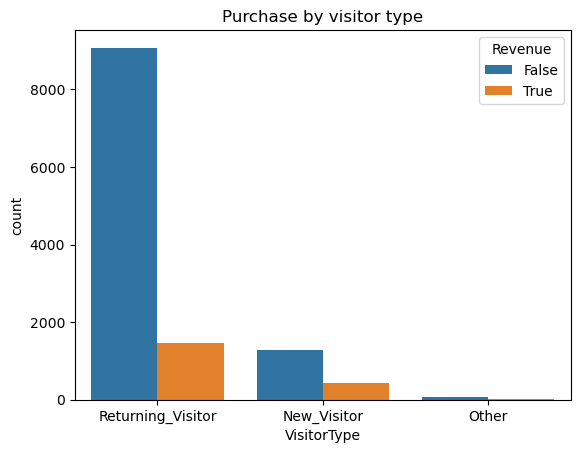

In [74]:
# for catagorial data
sns.countplot(x='VisitorType', hue='Revenue',data= df)
plt.title("Purchase by visitor type")
plt.show()
# we will drop "other" and binary encode it.

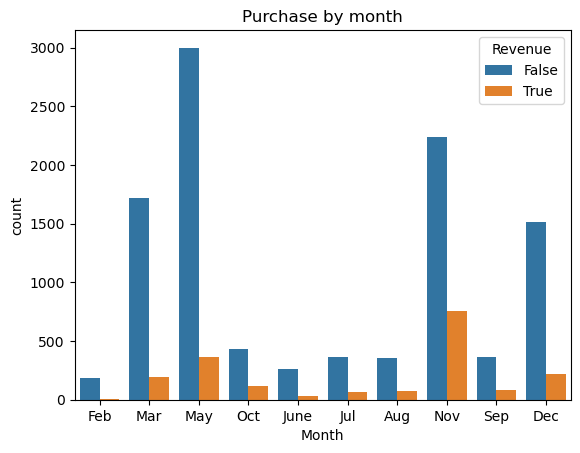

In [72]:
# what month gives most revenue
sns.countplot(data=df, x="Month", hue="Revenue")
plt.title("Purchase by month")
plt.show()
# we will one hot encode this.

Text(0.5, 1.0, 'Distribution of page vales')

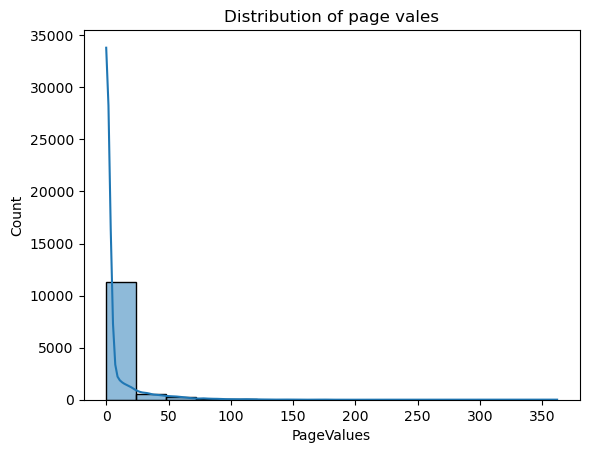

In [86]:
# Ploting numerical data.
sns.histplot(df["PageValues"], kde=True) # KDE tells about the density.
plt.title("Distribution of page vales")

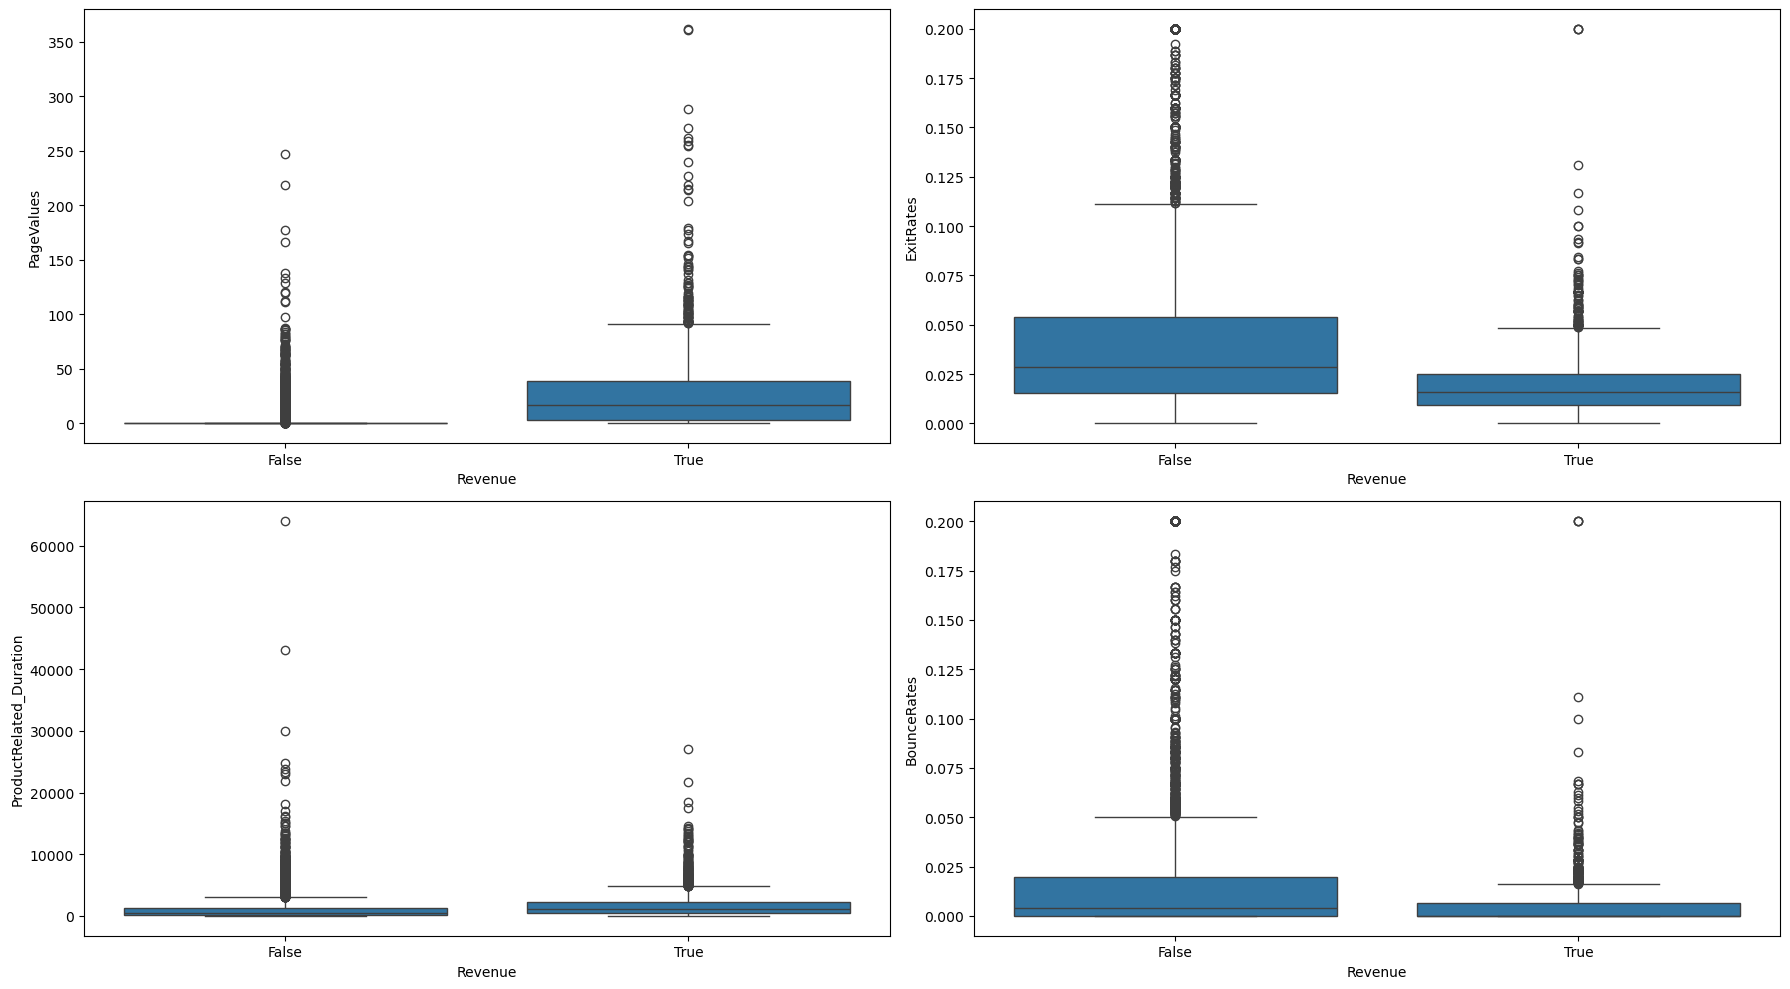

In [92]:
fig, axes= plt.subplots(2,2, figsize=(18,10))

sns.boxplot(data=df, ax=axes[0,0], x="Revenue",y="PageValues")
sns.boxplot(data=df, ax=axes[0,1], x="Revenue",y="ExitRates")
sns.boxplot(data=df, ax=axes[1,0], x="Revenue",y="ProductRelated_Duration")
sns.boxplot(data=df, ax=axes[1,1], x="Revenue",y="BounceRates")

plt.tight_layout()

In [104]:
df[["PageValues","ProductRelated_Duration"]].describe()
# so we can to cap the extreme outliers of ProductRelated_Duration

,PageValues,ProductRelated_Duration
count,12330.000000,12330.000000
mean,5.889258,1194.746220
std,18.568437,1913.669288
min,0.000000,0.000000
25%,0.000000,184.137500
50%,0.000000,598.936905
75%,0.000000,1464.157214
max,361.763742,63973.522230


# Feature Eng.

In [156]:
# encoding values
from sklearn.preprocessing import LabelEncoder ,OneHotEncoder
col=["Month"]
one= OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded= one.fit_transform(df[col])

encoded_df= pd.DataFrame(encoded, columns=one.get_feature_names_out(col), index=df.index)
df= pd.concat([df.drop(columns=col), encoded_df], axis=1)

In [158]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Revenue,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,False,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,False,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,False,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [171]:
# Label encoding 
df= df[df["VisitorType"] != "Other"].copy()
le= LabelEncoder()
df["VisitorType"]= le.fit_transform(df["VisitorType"])

# Handeling bool values
bool_col= df.select_dtypes(include="bool").columns
df[bool_col]= df[bool_col].astype(int)

In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12245 entries, 0 to 12329
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12245 non-null  int64  
 1   Administrative_Duration  12245 non-null  float64
 2   Informational            12245 non-null  int64  
 3   Informational_Duration   12245 non-null  float64
 4   ProductRelated           12245 non-null  int64  
 5   ProductRelated_Duration  12245 non-null  float64
 6   BounceRates              12245 non-null  float64
 7   ExitRates                12245 non-null  float64
 8   PageValues               12245 non-null  float64
 9   SpecialDay               12245 non-null  float64
 10  OperatingSystems         12245 non-null  int64  
 11  Browser                  12245 non-null  int64  
 12  Region                   12245 non-null  int64  
 13  TrafficType              12245 non-null  int64  
 14  VisitorType              12

<Axes: >

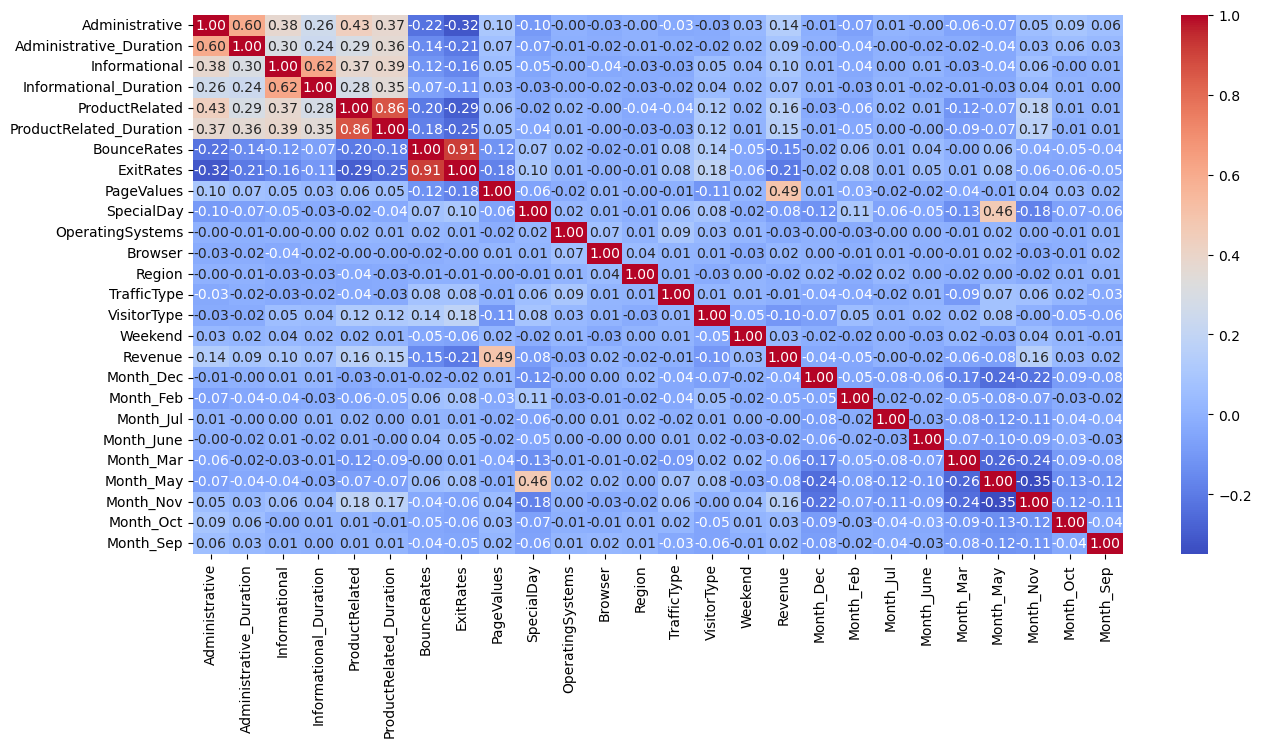

In [199]:
# corelation Heatmap
num_col=df.select_dtypes(include="number")
coor_mat= num_col.corr()
plt.figure(figsize=(15,7))
sns.heatmap(
    coor_mat,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

In [203]:
# Since bounce rates and exit rates show high coorelation and they represent almost the same thing "EXIT" we will drop exit rate since bounce rate gurentees visit of atleast one page.
df= df.drop("ExitRates",axis=1)

# Training with pre-pruning

In [216]:
# we will use pre-pruning and for that also we will grid search.

X=df.drop("Revenue", axis=1)
y=df["Revenue"]
X_train, X_test, y_train, y_test= train_test_split(X,y, random_state=42, test_size=0.3)

In [222]:
from sklearn.model_selection import GridSearchCV

model= DecisionTreeClassifier(random_state=42)

para_grid={
    "max_depth": [3,5,7,9],
    "min_samples_split" : [4,6,8,10],
    "min_samples_leaf": [5,7,8],
    "criterion":["gini"]
}
grid = GridSearchCV(
    estimator=model,
    param_grid=para_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train,y_train)

print("Scoring", grid.best_score_)
print("Best Parameters", grid.best_params_)

Scoring 0.6358050340045839
Best Parameters {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 4}


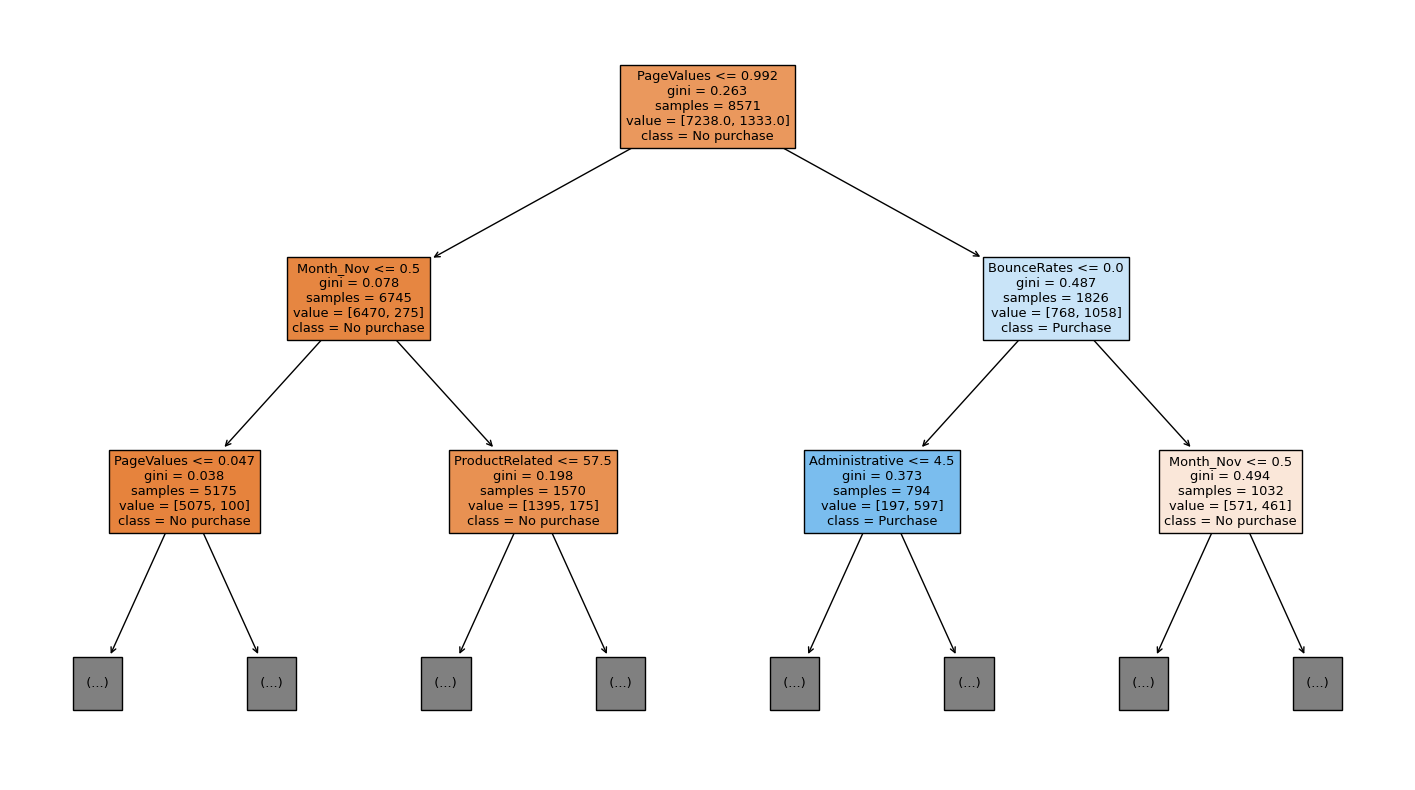

In [232]:
# Plotting the best tree
from sklearn.tree import plot_tree
best_model= grid.best_estimator_

plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["No purchase","Purchase"],
    filled=True,
    max_depth=2
)
plt.show()